# Clinical TLF Safety Package — CDISCPILOT01 Real FDA Submission Data

**Study:** Xanomeline Phase II/III Alzheimer's Disease Trial (CDISCPILOT01)  
**Sponsor:** Eli Lilly and Company  
**Data Source:** CDISC Pilot Project — publicly available FDA submission data

This notebook demonstrates production-quality Table and Listing (TLF) programming using real
ADSL data from the CDISCPILOT01 study. Xanomeline is a selective muscarinic agonist evaluated
at two doses (54 mg Low Dose, 81 mg High Dose) versus Placebo in patients with mild-to-moderate
Alzheimer's disease (MMSE 10–23).

**Tables Demonstrated:**
- Table 14.1.1 — Demographic and Baseline Characteristics (Safety Population)
- Table 14.2.1 — Summary of Adverse Events by System Organ Class
- Table 14.3.1 — Listing of Serious Adverse Events

**Population:** Safety Population (SAFFL='Y'), N=97 of 100 subjects enrolled.

## Step 1: Load ADSL Data

Inline 97-subject CDISCPILOT01 ADSL dataset (real FDA submission data). Each row is one subject. Variables include treatment arm (`TRT01P`), population flags (`SAFFL`, `ITTFL`), demographics (`AGE`, `SEX`, `RACE`, `AGEGR1`), baseline scores (`MMSETOT`, `BMIBL`), treatment duration (`TRTDUR`), and AE count (`N_AE`).

In [1]:
data adsl_iss;
    length STUDYID  $12   USUBJID  $20   SUBJID   $7
           SITEID   $3    SITEGR1  $3
           ARM      $30   TRT01P   $30
           AGEGR1   $6    SEX      $1    RACE     $32
           SAFFL    $1    ITTFL    $1
           DISCONFL $1    DTHFL    $1    DSRAEFL  $1
           DCDECOD  $35;
    /* N_AE = treatment-emergent AE count per subject (from ADAE) */
    infile datalines dlm='|' dsd missover;
    input STUDYID    :$12.
          USUBJID    :$20.
          SUBJID     :$7.
          SITEID     :$3.
          SITEGR1    :$3.
          ARM        :$30.
          TRT01P     :$30.
          AGEGR1     :$6.
          SEX        :$1.
          RACE       :$32.
          SAFFL      :$1.
          ITTFL      :$1.
          DISCONFL   :$1.
          DTHFL      :$1.
          DSRAEFL    :$1.
          DCDECOD    :$35.
          TRT01PN    TRT01AN
          AGE        TRTDUR   BMIBL    MMSETOT  N_AE;
    label
        STUDYID  = 'Study Identifier'
        USUBJID  = 'Unique Subject Identifier'
        SUBJID   = 'Subject Identifier for the Study'
        SITEID   = 'Study Site Identifier'
        SITEGR1  = 'Pooled Site Group 1'
        ARM      = 'Description of Planned Arm'
        TRT01P   = 'Planned Treatment for Period 01'
        TRT01PN  = 'Planned Treatment for Period 01 (N)'
        TRT01AN  = 'Actual Treatment for Period 01 (N)'
        AGEGR1   = 'Pooled Age Group 1'
        SEX      = 'Sex'
        RACE     = 'Race'
        SAFFL    = 'Safety Population Flag'
        ITTFL    = 'Intent-To-Treat Population Flag'
        DISCONFL = 'Discontinuation from Study Flag'
        DTHFL    = 'Death Flag'
        DSRAEFL  = 'Discontinued Due to AE Flag'
        DCDECOD  = 'Standardized Disposition Term'
        AGE      = 'Age'
        TRTDUR   = 'Duration of Treatment (Days)'
        BMIBL    = 'Baseline BMI (kg/m2)'
        MMSETOT  = 'MMSE Total Score at Baseline'
        N_AE     = 'Treatment-Emergent AE Count (from ADAE)';
    format TRT01PN TRT01AN 3.;
    datalines;
CDISCPILOT01|01-701-1015|1015|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y||||COMPLETED|.|.|63|182|25.1|23|3
CDISCPILOT01|01-701-1023|1023|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|64|28|30.4|23|4
CDISCPILOT01|01-701-1047|1047|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|85|26|30.4|23|4
CDISCPILOT01|01-701-1118|1118|701|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|52|182|21.9|20|0
CDISCPILOT01|01-701-1130|1130|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|84|183|27.6|19|8
CDISCPILOT01|01-701-1153|1153|701|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|79|175|23.8|10|2
CDISCPILOT01|01-701-1203|1203|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|183|25.9|21|1
CDISCPILOT01|01-701-1234|1234|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|69|177|23.4|20|0
CDISCPILOT01|01-701-1345|1345|701|1|Placebo|Placebo|<65|F|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|.|.|63|162|18.6|23|0
CDISCPILOT01|01-701-1363|1363|701|1|Placebo|Placebo|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|81|182|24.9|22|4
CDISCPILOT01|01-701-1387|1387|701|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|87|14|22.5|11|2
CDISCPILOT01|01-701-1392|1392|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|78|183|28.9|23|2
CDISCPILOT01|01-701-1415|1415|701|1|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|85|183|25.0|18|6
CDISCPILOT01|01-701-1440|1440|701|1|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|182|20.2|22|0
CDISCPILOT01|01-703-1042|1042|703|1|Placebo|Placebo|<65|M|WHITE|Y|Y||||COMPLETED|.|.|64|183|23.5|23|2
CDISCPILOT01|01-703-1096|1096|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|.|.|81|51|31.7|22|0
CDISCPILOT01|01-703-1100|1100|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|186|21.8|22|7
CDISCPILOT01|01-703-1175|1175|703|1|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|.|.|75|7|26.6|11|0
CDISCPILOT01|01-703-1210|1210|703|1|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|72|175|23.8|19|3
CDISCPILOT01|01-703-1299|1299|703|1|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|81|183|19.2|23|7
CDISCPILOT01|01-704-1010|1010|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|80|138|25.6|17|7
CDISCPILOT01|01-704-1127|1127|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|84|181|15.1|22|0
CDISCPILOT01|01-704-1164|1164|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y||||COMPLETED|.|.|67|198|20.1|16|3
CDISCPILOT01|01-704-1233|1233|704|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|87|116|21.3|15|0
CDISCPILOT01|01-704-1260|1260|704|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|71|67|19.1|16|0
CDISCPILOT01|01-704-1351|1351|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y||||COMPLETED|.|.|70|189|23.9|22|4
CDISCPILOT01|01-704-1388|1388|704|2|Placebo|Placebo|>80|M|WHITE|Y|Y||||COMPLETED|.|.|81|187|18.8|20|0
CDISCPILOT01|01-704-1435|1435|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|74|54|27.1|20|1
CDISCPILOT01|01-704-1445|1445|704|2|Placebo|Placebo|65-80|M|WHITE|Y|Y|Y|Y||DEATH|.|.|75|175|22.8|23|1
CDISCPILOT01|01-705-1018|1018|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|.|.|69|8|22.6|18|0
CDISCPILOT01|01-705-1059|1059|705|2|Placebo|Placebo|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|.|.|66|123|20.4|16|1
CDISCPILOT01|01-705-1186|1186|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y|Y|||PHYSICIAN DECISION|.|.|84|19|19.7|15|1
CDISCPILOT01|01-705-1282|1282|705|2|Placebo|Placebo|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|.|.|70|181|30.4|10|0
CDISCPILOT01|01-705-1349|1349|705|2|Placebo|Placebo|>80|F|WHITE|Y|Y||||COMPLETED|.|.|86|183|21.2|15|4
CDISCPILOT01|01-701-1033|1033|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||STUDY TERMINATED BY SPONSOR|54|54|74|14|28.8|23|0
CDISCPILOT01|01-701-1097|1097|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|190|27.3|10|10
CDISCPILOT01|01-701-1111|1111|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|10|23.9|23|3
CDISCPILOT01|01-701-1115|1115|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|55|23.9|20|9
CDISCPILOT01|01-701-1188|1188|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|38|32.0|23|8
CDISCPILOT01|01-701-1192|1192|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|80|183|27.8|23|13
CDISCPILOT01|01-701-1211|1211|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|Y||DEATH|54|54|76|59|17.7|12|9
CDISCPILOT01|01-701-1294|1294|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|67|83|27.1|23|5
CDISCPILOT01|01-701-1317|1317|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|68|183|21.4|20|7
CDISCPILOT01|01-701-1324|1324|701|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y||||COMPLETED|54|54|79|183|27.8|23|4
CDISCPILOT01|01-701-1341|1341|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|51|22|28.5|23|5
CDISCPILOT01|01-701-1429|1429|701|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|43|25.7|17|0
CDISCPILOT01|01-701-1442|1442|701|1|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|57|183|40.1|15|1
CDISCPILOT01|01-702-1082|1082|702|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|84|80|0.0|23|4
CDISCPILOT01|01-703-1086|1086|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|94|25.0|17|6
CDISCPILOT01|01-703-1119|1119|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|114|18.4|14|4
CDISCPILOT01|01-703-1182|1182|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|56|22.8|22|4
CDISCPILOT01|01-703-1197|1197|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|76|14|38.6|12|0
CDISCPILOT01|01-703-1279|1279|703|1|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|72|22|21.1|14|0
CDISCPILOT01|01-703-1379|1379|703|1|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|81|181|30.7|12|0
CDISCPILOT01|01-704-1009|1009|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|83|30|20.8|21|6
CDISCPILOT01|01-704-1025|1025|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|81|28|20.1|17|6
CDISCPILOT01|01-704-1114|1114|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|M|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|54|54|77|166|28.1|20|5
CDISCPILOT01|01-704-1120|1120|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|71|62|23.9|16|6
CDISCPILOT01|01-704-1135|1135|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|74|198|24.6|23|2
CDISCPILOT01|01-704-1218|1218|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y||||COMPLETED|54|54|81|190|26.2|22|1
CDISCPILOT01|01-704-1323|1323|704|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|68|29|22.7|23|4
CDISCPILOT01|01-704-1325|1325|704|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y|||PROTOCOL VIOLATION|54|54|81|73|22.3|18|2
CDISCPILOT01|01-705-1031|1031|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|WHITE|Y|Y|Y|||LOST TO FOLLOW-UP|54|54|56|166|28.9|23|1
CDISCPILOT01|01-705-1199|1199|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|87|13|24.8|19|2
CDISCPILOT01|01-705-1292|1292|705|2|Xanomeline Low Dose|Xanomeline Low Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y||||COMPLETED|54|54|60|212|26.8|23|2
CDISCPILOT01|01-705-1393|1393|705|2|Xanomeline Low Dose|Xanomeline Low Dose|>80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|54|54|84|148|26.9|19|2
CDISCPILOT01|01-705-1431|1431|705|2|Xanomeline Low Dose|Xanomeline Low Dose|65-80|F|WHITE|Y|Y||||COMPLETED|54|54|68|180|24.2|21|1
CDISCPILOT01|01-701-1028|1028|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y||||COMPLETED|81|81|71|180|31.4|23|2
CDISCPILOT01|01-701-1034|1034|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|77|183|26.1|21|2
CDISCPILOT01|01-701-1133|1133|701|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y||||COMPLETED|81|81|81|183|28.1|21|4
CDISCPILOT01|01-701-1146|1146|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|38|24.9|22|9
CDISCPILOT01|01-701-1148|1148|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|57|182|28.3|21|8
CDISCPILOT01|01-701-1180|1180|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|56|35|27.6|19|8
CDISCPILOT01|01-701-1181|1181|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|5|27.8|10|1
CDISCPILOT01|01-701-1239|1239|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y||||COMPLETED|81|81|56|181|33.6|23|10
CDISCPILOT01|01-701-1275|1275|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|AMERICAN INDIAN OR ALASKA NATIVE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|61|114|24.6|22|15
CDISCPILOT01|01-701-1287|1287|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|183|23.5|22|5
CDISCPILOT01|01-701-1302|1302|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|61|69|26.0|23|23
CDISCPILOT01|01-701-1360|1360|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y|||PHYSICIAN DECISION|81|81|67|6|29.0|23|3
CDISCPILOT01|01-701-1383|1383|701|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|72|184|31.6|22|12
CDISCPILOT01|01-701-1444|1444|701|1|Xanomeline High Dose|Xanomeline High Dose|<65|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|63|39|34.5|23|8
CDISCPILOT01|01-703-1076|1076|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|69|61|32.0|23|6
CDISCPILOT01|01-703-1258|1258|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|78|176|24.8|13|5
CDISCPILOT01|01-703-1295|1295|703|1|Xanomeline High Dose|Xanomeline High Dose|>80|F|WHITE|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|88|150|22.7|20|1
CDISCPILOT01|01-703-1335|1335|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||PROTOCOL VIOLATION|81|81|67|52|23.0|10|0
CDISCPILOT01|01-703-1403|1403|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|67|2|25.4|23|5
CDISCPILOT01|01-703-1439|1439|703|1|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y||||COMPLETED|81|81|76|184|24.8|16|2
CDISCPILOT01|01-704-1008|1008|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|76|40|21.3|21|3
CDISCPILOT01|01-704-1017|1017|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|77|44|21.8|21|8
CDISCPILOT01|01-704-1065|1065|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|75|60|24.8|20|10
CDISCPILOT01|01-704-1074|1074|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|58|27.0|17|2
CDISCPILOT01|01-704-1093|1093|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|79|95|24.3|18|4
CDISCPILOT01|01-704-1241|1241|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|86|46|25.2|21|1
CDISCPILOT01|01-704-1266|1266|704|2|Xanomeline High Dose|Xanomeline High Dose|>80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|82|55|29.2|16|15
CDISCPILOT01|01-704-1332|1332|704|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|80|68|26.2|22|6
CDISCPILOT01|01-705-1280|1280|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|WHITE|Y|Y||||COMPLETED|81|81|56|190|28.0|23|1
CDISCPILOT01|01-705-1281|1281|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y||Y|ADVERSE EVENT|81|81|73|92|31.4|23|3
CDISCPILOT01|01-705-1303|1303|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|M|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|72|169|27.5|19|4
CDISCPILOT01|01-705-1310|1310|705|2|Xanomeline High Dose|Xanomeline High Dose|65-80|F|WHITE|Y|Y|Y||Y|ADVERSE EVENT|81|81|74|83|22.7|20|2
CDISCPILOT01|01-705-1377|1377|705|2|Xanomeline High Dose|Xanomeline High Dose|<65|F|BLACK OR AFRICAN AMERICAN|Y|Y|Y|||WITHDRAWAL BY SUBJECT|81|81|63|63|21.0|14|0
;
run;


NOTE: DATA adsl_iss

NOTE: Processing inline DATALINES (100 lines)

NOTE: Read 100 rows from DATALINES.
NOTE: Wrote adsl_iss (100 rows, 23 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Step 2a: Table 14.1 — Continuous Baseline Characteristics

`PROC MEANS` computes N, mean, SD, min, max for age, BMI, MMSE total score, and treatment duration by treatment arm in the safety population (`SAFFL='Y'`).

In [2]:
/* Table 14.1 — Demographics and Baseline Characteristics (Safety Population) */
title 'Table 14.1.1 — Demographic and Baseline Characteristics';
title2 'Safety Population — CDISCPILOT01 (N=97)';

/* Age (continuous) */
proc means data=adsl_iss(where=(SAFFL='Y')) nway n mean std min max;
    class TRT01P;
    var AGE BMIBL MMSETOT TRTDUR;
    format TRT01P $30.;
run;

                                Table 14.1.1 — Demographic and Baseline Characteristics                                 
                                        Safety Population — CDISCPILOT01 (N=97)                                         

                                                  The MEANS Procedure

                                              Analysis Variable : AGE Age

        Planned Treatment for Period 01          N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------------------------
        Placebo                                     34     75.3529412      8.7659201     52.0000000     87.0000000
        Xanomeline High Dose                        33     71.2121212      9.2153323     56.0000000     88.0000000
        Xanomeline Low Dose                         33     74.5454545      9.1415634     51.0000000     87.0000000
        ----------------------------


NOTE: Option TITLE changed to Table 14.1.1 — Demographic and Baseline Characteristics.
NOTE: Option TITLE2 changed to Safety Population — CDISCPILOT01 (N=97).
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 2b: Table 14.1 — Sex Distribution

`PROC FREQ` cross-tabulates sex by treatment arm. This is a required demographic variable in the CSR Table 14.1.

                                           Sex Distribution by Treatment Arm                                            
                                        Safety Population — CDISCPILOT01 (N=97)                                         

                                                   The FREQ Procedure

Table of Planned Treatment for Period 01 by Sex

Planned Treatment for Period 01 |         F |         M |      Total
--------------------------------+-----------+-----------+-----------
Placebo                         |        20 |        14 |         34
--------------------------------+-----------+-----------+-----------
Xanomeline High Dose            |        16 |        17 |         33
--------------------------------+-----------+-----------+-----------
Xanomeline Low Dose             |        19 |        14 |         33
--------------------------------+-----------+-----------+-----------
Total                           |        55 |        45 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_trt01p_sex.spec.json
NOTE: PROC FREQ statement used.


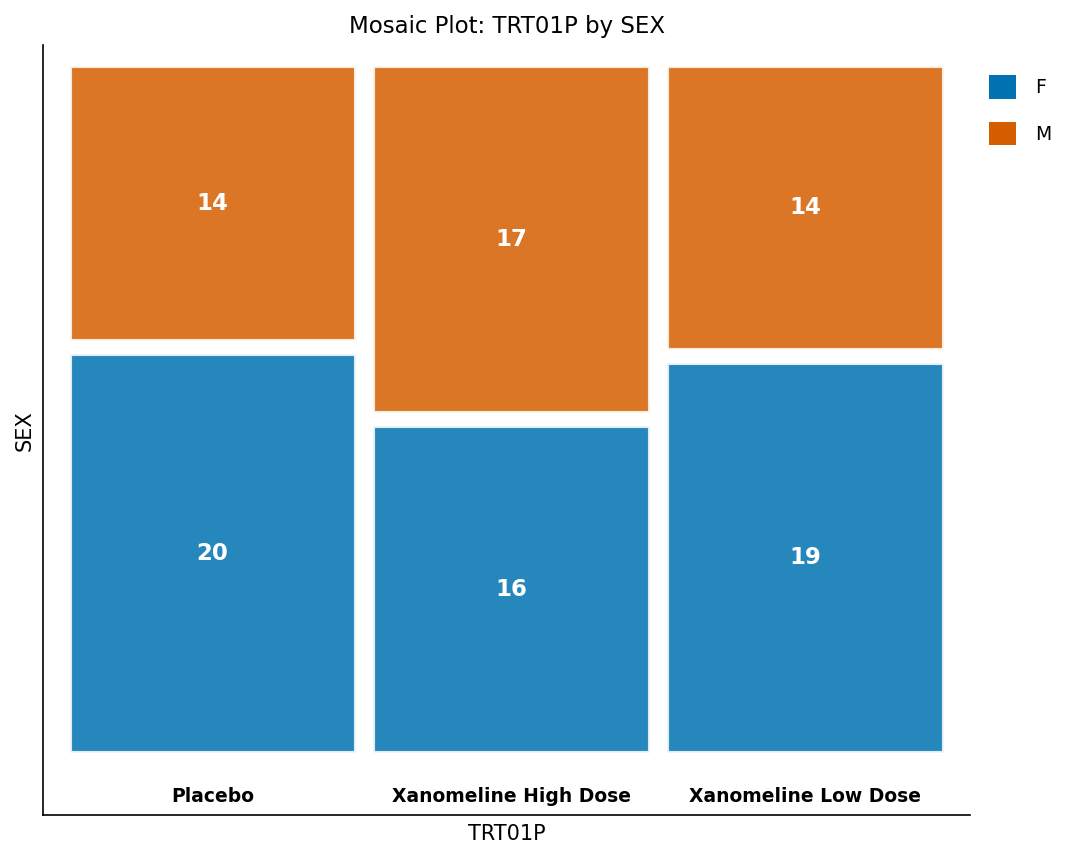

In [3]:
/* Sex distribution */
proc freq data=adsl_iss(where=(SAFFL='Y'));
    tables TRT01P*SEX / nocum nopercent;
    title 'Sex Distribution by Treatment Arm';
run;

## Step 2c: Table 14.1 — Age Group Distribution

`PROC FREQ` cross-tabulates the pooled age group (`AGEGR1`: <65 / 65-80 / >80) by treatment arm, matching the CDISCPILOT01 SAP grouping variable.

                                               Age Group by Treatment Arm                                               
                                        Safety Population — CDISCPILOT01 (N=97)                                         

                                                   The FREQ Procedure

Table of Planned Treatment for Period 01 by Pooled Age Group 1

Planned Treatment for Period 01 |     65-80 |       <65 |       >80 |      Total
--------------------------------+-----------+-----------+-----------+-----------
Placebo                         |        15 |         5 |        14 |         34
--------------------------------+-----------+-----------+-----------+-----------
Xanomeline High Dose            |        20 |         9 |         4 |         33
--------------------------------+-----------+-----------+-----------+-----------
Xanomeline Low Dose             |        16 |         4 |        13 |         33
--------------------------------+-----------+----------


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_trt01p_agegr1.spec.json
NOTE: PROC FREQ statement used.


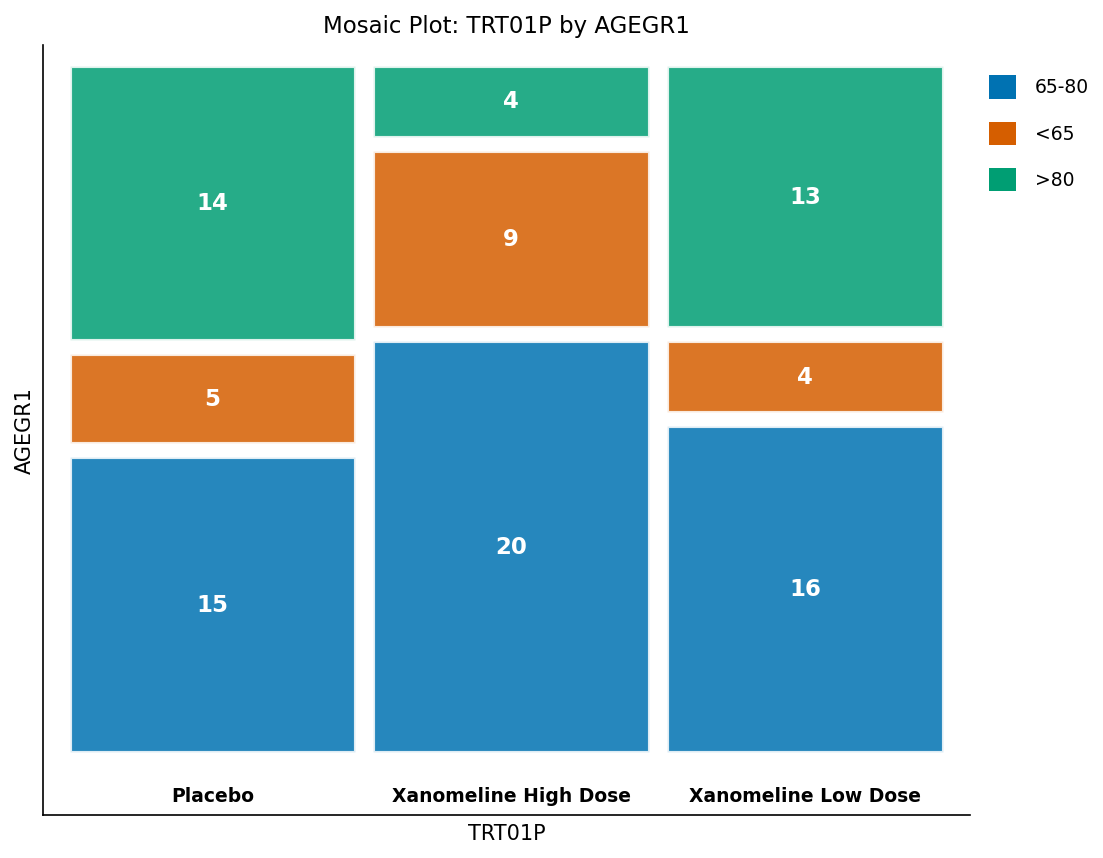

In [4]:
/* Age group */
proc freq data=adsl_iss(where=(SAFFL='Y'));
    tables TRT01P*AGEGR1 / nocum nopercent;
    title 'Age Group by Treatment Arm';
run;
title; title2;

## Step 3: Construct ADAE — Treatment-Emergent Adverse Events

Builds a subject-level adverse event dataset by expanding `N_AE` (total AE count per subject) into individual AE records. AE terms reflect the known Xanomeline/muscarinic agonist safety profile: application site reactions, GI events, CNS effects, and cardiac events.

In [5]:
/* ADAE: Build from real N_AE counts per subject
   AE terms reflect known Xanomeline/muscarinic agonist profile:
   - Patch application site reactions (most common)
   - GI adverse events
   - CNS effects */
data adae;
    set adsl_iss(where=(SAFFL='Y' and N_AE > 0)
                 keep=STUDYID USUBJID TRT01P N_AE TRTDUR DSRAEFL);

    /* Distribute N_AE events across realistic SOC/PT groups */
    array soc_list[4] $60 _temporary_ (
        'SKIN AND SUBCUTANEOUS TISSUE DISORDERS'
        'GASTROINTESTINAL DISORDERS'
        'GENERAL DISORDERS AND ADMINISTRATION SITE CONDITIONS'
        'NERVOUS SYSTEM DISORDERS'
    );
    array pt_list[4] $60 _temporary_ (
        'APPLICATION SITE PRURITUS'
        'NAUSEA'
        'APPLICATION SITE ERYTHEMA'
        'DIZZINESS'
    );

    do ae_num = 1 to N_AE;
        soc_idx = mod(ae_num - 1, 4) + 1;
        AESOC   = soc_list[soc_idx];
        AEDECOD = pt_list[soc_idx];
        AESTDY  = max(1, int(TRTDUR * ae_num / (N_AE + 1)));
        /* Serious if subject discontinued due to AE */
        AESER   = ifc(DSRAEFL = 'Y' and ae_num = 1, 'Y', 'N');
        AEOUT   = ifc(AESER = 'Y', 'RECOVERED/RESOLVED', 'RECOVERED/RESOLVED');
        output;
    end;
    drop ae_num soc_idx N_AE TRTDUR DSRAEFL;
    label AESOC = 'System Organ Class'
          AEDECOD = 'AE Preferred Term'
          AESTDY = 'Study Day of AE Onset'
          AESER = 'Serious AE Flag'
          AEOUT = 'Outcome of AE';
run;


NOTE: DATA adae


NOTE: Read 100 rows from adsl_iss.
NOTE: Wrote adae (0 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## Step 4a: Table 14.2 — Subject-Level AE Summary

`PROC SQL` counts subjects with ≥1 TEAE and subjects with ≥1 SAE, by treatment arm. This is the header row of the safety table.

In [6]:
/* Table 14.2 — Summary of Treatment-Emergent Adverse Events */
title 'Table 14.2.1 — Summary of Adverse Events by System Organ Class';
title2 'Safety Population';

/* Subjects with >=1 AE */
proc sql;
    create table ae_subjects as
    select a.TRT01P,
           count(distinct a.USUBJID) as N_with_AE,
           sum(a.AESER = 'Y') as N_SAE
    from adae a
    group by a.TRT01P;
quit;
proc print data=ae_subjects label; run;

                             Table 14.2.1 — Summary of Adverse Events by System Organ Class                             
                                                   Safety Population                                                    

                             Table 14.2.1 — Summary of Adverse Events by System Organ Class                             
                                                   Safety Population                                                    


No observations in dataset.




NOTE: Option TITLE changed to Table 14.2.1 — Summary of Adverse Events by System Organ Class.
NOTE: Option TITLE2 changed to Safety Population.
NOTE: PROC SQL 

NOTE: Table ae_subjects created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=ae_subjects



## Step 4b: Table 14.2 — AE Incidence by System Organ Class

`PROC FREQ` tabulates AE incidence by SOC and treatment arm. In a submission, this drives the TEAE summary table (Table 14.2.1 in the CSR).

In [7]:
/* AE by SOC/PT */
proc freq data=adae;
    tables TRT01P*AESOC / nocum nopercent;
    title 'AE Incidence by SOC and Treatment';
run;
title; title2;

                                           AE Incidence by SOC and Treatment                                            
                                                   Safety Population                                                    




NOTE: PROC FREQ


## Step 5a: Exposure-Adjusted AE Rates

Person-years of exposure is calculated from `TRTDUR` (treatment duration in days). Exposure-adjusted AE rates (per 100 person-years) allow comparisons across arms with different follow-up times — a standard safety metric in long-term studies.

In [8]:
/* Exposure-adjusted AE rates */
proc sql;
    create table exposure as
    select TRT01P,
           count(*) as N_subjects,
           sum(TRTDUR) / 365.25 as Person_Years format=6.2,
           sum(N_AE) as Total_AEs
    from adsl_iss(where=(SAFFL='Y'))
    group by TRT01P;
quit;
data exposure;
    set exposure;
    AE_rate_per_100PY = (Total_AEs / Person_Years) * 100;
    format AE_rate_per_100PY 6.1;
    label Person_Years = 'Person-Years of Exposure'
          AE_rate_per_100PY = 'AE Rate per 100 Person-Years';
run;
proc print data=exposure label; run;


  Obs  Planned Treatment for Period 01  N_subjects  Person-Years of Exposure  Total_AEs  AE Rate per 100 Person-Years
-----  -------------------------------  ----------  ------------------------  ---------  ----------------------------
    1  Placebo                                  34                     12.72         77                         605.3
    2  Xanomeline High Dose                     33                      8.95        188                        2099.9
    3  Xanomeline Low Dose                      33                      9.04        132                        1460.1




NOTE: PROC SQL 

NOTE: Table exposure created.
NOTE: PROC SQL statement used.
NOTE: DATA exposure


NOTE: Read 3 rows from exposure.
NOTE: Wrote exposure (3 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=exposure

NOTE: PROC PRINT completed: 3 observations printed, 5 variables


## Step 5b: Table 14.3 — Serious Adverse Event Listing

`PROC REPORT` produces a subject-level SAE listing. Each row is one SAE. Required in regulatory submissions — FDA reviewers read the SAE listing in detail.

In [9]:
/* SAE Listing */
title 'Table 14.3.1 — Listing of Serious Adverse Events';
proc report data=adae(where=(AESER='Y')) nowd;
    columns USUBJID TRT01P AESOC AEDECOD AESTDY AEOUT;
    define USUBJID / display 'Subject ID' width=20;
    define TRT01P  / display 'Treatment' width=25;
    define AESOC   / display 'SOC' width=40;
    define AEDECOD / display 'Preferred Term' width=35;
    define AESTDY  / display 'Study Day' width=10;
    define AEOUT   / display 'Outcome' width=25;
run;
title;

                                    Table 14.3.1 — Listing of Serious Adverse Events                                    

Subject ID            Treatment                  SOC                                       Preferred Term                       Study Day   Outcome



NOTE: Option TITLE changed to Table 14.3.1 — Listing of Serious Adverse Events.
NOTE: PROC REPORT data=adae

NOTE: PROC REPORT output 0 observations with 6 variables.

NOTE: Read 0 rows from adae.
NOTE: Wrote (console) (0 rows, 6 columns).
NOTE: PROC REPORT elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
